# 🤖 EfficientNetB0 Transfer Learning – staged fine-tuning

**Regression model for spherical equivalent estimation (`target_SE`) from full-preprocessed fundus images**

This notebook adapts the previous EfficientNetB0 transfer learning classification pipeline to a **regression task**.

Instead of predicting the probability of myopia, the model predicts a continuous value:

`target_SE` = spherical equivalent in diopters.

The model is trained in three stages:

1. **Stage 1:** EfficientNetB0 frozen, train only the regression head.
2. **Stage 2:** load Stage 1, unfreeze the last 20 EfficientNetB0 layers, fine-tune with lower learning rate.
3. **Stage 3:** load Stage 2, unfreeze the last 40 EfficientNetB0 layers, fine-tune with even lower learning rate.
4. **Stage 4:** load Stage 3, unfreeze the last 60 EfficientNetB0 layers, fine-tune with a very small learning rate.
5. **Stage 5:** load Stage 4, unfreeze the last 80 EfficientNetB0 layers, fine-tune cautiously with a very small learning rate.


-> Stage 1 es el modelo más “puro” de transfer learning: EfficientNetB0 está congelado y solo se entrena la cabeza nueva de clasificación/regresión. Es decir, se usa EfficientNetB0 como extractor fijo de características.

Stage 2-5 son pruebas de fine-tuning: se carga el modelo anterior, se descongela parte de EfficientNetB0 y se deja que algunas capas finales también aprendan con nuestras imágenes de retina.

## 🧠 0. What changes from classification to regression?

Main changes:

| Classification | Regression |
|---|---|
| Target: `class_label` | Target: `target_SE` |
| Output: `Dense(1, sigmoid)` | Output: `Dense(1, linear)` |
| Loss: Binary Focal Crossentropy | Loss: MSE by default |
| Metrics: AUC, accuracy, AP, recall | Metrics: MAE, RMSE, R² |
| EarlyStopping on `val_auc` | EarlyStopping on `val_mae` |
| Curves: ROC / PR / Confusion matrix | Curves: prediction scatter / residuals |

EfficientNetB0 is still used as a pretrained feature extractor, but the final head now learns to estimate a numerical refractive error instead of a class probability.

## ⚙️ 1. Imports and reproducibility


In [1]:
from __future__ import annotations

#import argparse - not needed
import importlib
import sys
from pathlib import Path
from types import SimpleNamespace #extra addition
from typing import Any

import numpy as np
import pandas as pd
import tensorflow as tf
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.model_selection import train_test_split
from tensorflow import keras
from tensorflow.keras import layers
import matplotlib.pyplot as plt #extra addition

#extra addition ----------------------------------------
SEED = 42 #
tf.keras.utils.set_random_seed(SEED)

try:
    tf.config.experimental.enable_op_determinism()
except Exception as e:
    print("Determinism could not be enabled:", e)

print("TensorFlow version:", tf.__version__)


TensorFlow version: 2.19.0


## 🧾 2. Experiment configuration

These values can be adapteed if a different experiment is wanted (adapting the number of epochs, batch size...)

The notebook reads most paths from `config.yaml`.

For this notebook:
- `EXPERIMENT = "full_preproc"`
- images are taken from the full preprocessing table
- splits are taken from the regression split folder
- models are saved in the same full-preprocessing model output folder, using regression-specific names

Important detail: this EfficientNetB0 implementation keeps images in the **0–255 pixel range**. This is different from some of the previous notebooks where images were converted to **0–1**.


In [2]:
# Experiment selected in config.yaml
EXPERIMENT = "full_preproc"

# Model/loss settings
HEAD = "mlp"
EFFICIENTNET_WEIGHTS = "imagenet"

# Regression loss: "mse" for direct comparability with many regression models
# Might this to "huber" if training is unstable or very affected by outliers
REGRESSION_LOSS = "mse"
HUBER_DELTA = 1.0

# Training settings - extra addition (#)
EPOCHS = 15 #
BATCH_SIZE_OVERRIDE = None # - Use None to read batch size from config.yaml
BASE_LEARNING_RATE = 1e-4 #
EARLY_STOPPING_PATIENCE = 5 #
REDUCE_LR_PATIENCE = 5 #
VERBOSE = 1 #

# Optional: force a project root manually if automatic detection fails.
# Example: PROJECT_ROOT_OVERRIDE = r"C:/Users/Paula/Desktop/TFG_Biomed"
PROJECT_ROOT_OVERRIDE = None # Extra addition

STAGES = [
    {
        "stage": 1,
        "name": "stage1_frozen",
        "unfreeze_last_n_layers": 0,
        "lr_multiplier": 1.0,
    },
    {
        "stage": 2,
        "name": "stage2_unfreeze20",
        "unfreeze_last_n_layers": 20,
        "lr_multiplier": 0.1,
    },
    {
        "stage": 3,
        "name": "stage3_unfreeze40",
        "unfreeze_last_n_layers": 40,
        "lr_multiplier": 0.01,
    },
    {
        "stage": 4,
        "name": "stage4_unfreeze60",
        "unfreeze_last_n_layers": 60,
        "lr_multiplier": 0.005,
    },
    {
        "stage": 5,
        "name": "stage5_unfreeze80",
        "unfreeze_last_n_layers": 80,
        "lr_multiplier": 0.002,
    },
]

#extra addition
args = SimpleNamespace(
    epochs=EPOCHS,
    batch_size=BATCH_SIZE_OVERRIDE,
    learning_rate=BASE_LEARNING_RATE,
    early_stopping_patience=EARLY_STOPPING_PATIENCE,
    reduce_lr_patience=REDUCE_LR_PATIENCE,
    verbose=VERBOSE,
)


## 📁 3. Project paths

This cell searches for `config.yaml` and imports the helper functions from `src.paths`.

The notebook should be run from inside the project folder, or if failing, set `PROJECT_ROOT_OVERRIDE` in the previous cell.


In [3]:
def find_project_root(start: Path | None = None) -> Path: #extra addition: fixed for congif.yaml possible failure
    if PROJECT_ROOT_OVERRIDE is not None: 
        root = Path(PROJECT_ROOT_OVERRIDE).expanduser().resolve()
        if not (root / "config.yaml").exists():
            raise FileNotFoundError(f"config.yaml was not found in PROJECT_ROOT_OVERRIDE: {root}")
        return root

    root = (start or Path.cwd()).resolve()
    while not (root / "config.yaml").exists():
        if root == root.parent:
            raise FileNotFoundError(
                "config.yaml was not found. Run this notebook from inside the project "
                "or set PROJECT_ROOT_OVERRIDE in the configuration cell."
            )
        root = root.parent
    return root

PROJECT_ROOT = find_project_root()
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

importlib.invalidate_caches()

from src.paths import (  # noqa: E402
    get_experiment_paths,
    get_paths,
    load_config,
    validate_experiment_paths,
    validate_main_structure,
)

In [4]:
# parse_args function would be here, but I believe there is no longer need for it
def parse_args() -> argparse.Namespace:
    parser = argparse.ArgumentParser(
        description="Train only the FullPreproc binary myopia classification model."
    )
    parser.add_argument("--epochs", type=int, default=10)
    parser.add_argument("--batch-size", type=int, default=None)
    parser.add_argument("--learning-rate", type=float, default=1e-4)
    parser.add_argument(
        "--early-stopping-patience",
        type=int,
        default=15,
        help="Epochs without val_auc improvement before stopping training.",
    )
    parser.add_argument(
        "--reduce-lr-patience",
        type=int,
        default=5,
        help="Epochs without val_auc improvement before reducing the learning rate.",
    )
    parser.add_argument(
        "--verbose",
        type=int,
        choices=[0, 1, 2],
        default=1,
        help="Keras console verbosity: 0=silent, 1=progress bar, 2=one line per epoch.",
    )
    return parser.parse_args()


In [5]:
# These are extra additions to read variables from config.yaml

cfg = load_config(PROJECT_ROOT / "config.yaml")
paths = get_paths(cfg)
validate_main_structure(paths)

exp_paths = get_experiment_paths(cfg, EXPERIMENT)
validate_experiment_paths(exp_paths)

seed = int(cfg["settings"].get("seed", SEED))
image_size = tuple(cfg["settings"]["image_size"])
batch_size = args.batch_size or int(cfg["settings"]["batch_size"])

TABLE_PATH = exp_paths["table"]

# Regression splits
if "split_regression" in exp_paths:
    SPLIT_DIR = exp_paths["split_regression"]
else:
    raise KeyError(
        "exp_paths does not contain 'split_regression'. "
        "Check src/paths.py or config.yaml. You need a regression split folder."
    )

MODELS_DIR = exp_paths["models_experiment"] #from yaml
MODELS_DIR.mkdir(parents=True, exist_ok=True)

print("Project root:", PROJECT_ROOT)
print("Experiment:", EXPERIMENT)
print("Table path:", TABLE_PATH)
print("Regression splits:", SPLIT_DIR)
print("Models output:", MODELS_DIR)
print("Image size:", image_size)
print("Batch size:", batch_size)
print("Seed:", seed)

Project root: C:\Users\paula\0B_TFGBiomed_Exe
Experiment: full_preproc
Table path: C:\Users\paula\0B_TFGBiomed_Exe\Tables\MatchTables\Tabla_MatchImagenesConDatosClinicos_FullPreproc.xlsx
Regression splits: C:\Users\paula\0B_TFGBiomed_Exe\Splits\Regression\FullPreproc
Models output: C:\Users\paula\0B_TFGBiomed_Exe\ModelsToSave\WithDropout\FullPreproc
Image size: (224, 224)
Batch size: 32
Seed: 42


## 🧹 4. Load and clean the matched table

The table is expected to contain at least these columns:

- `image_path`
- `filename`
- `patient_id`

For regression, the required target column is `target_SE`.


In [6]:
def resolve_project_path(path: str | Path) -> Path:
    path = Path(path)
    if path.is_absolute():
        return path
    return PROJECT_ROOT / path

def resolve_project_path_str(path: str | Path) -> str:
    return str(resolve_project_path(path))

def load_and_clean_table(table_path: Path) -> pd.DataFrame:
    df = pd.read_excel(table_path)

    #extra addition:
    required_cols = {"image_path", "filename", "patient_id", "target_SE"}
    missing_cols = required_cols - set(df.columns)
    if missing_cols:
        raise ValueError(f"Missing required columns in matched table: {missing_cols}")

    df = df[df["image_path"].notna()].copy()
    df = df[df["target_SE"].notna()].copy()

    df["image_path"] = df["image_path"].astype(str)
    df["filename"] = df["filename"].astype(str)
    df["patient_id"] = df["patient_id"].astype(str).str.upper().str.strip()
    df["target_SE"] = pd.to_numeric(df["target_SE"], errors="coerce")

    df = df.dropna(subset=["image_path", "filename", "patient_id", "target_SE"]).copy()
    df["target_SE"] = df["target_SE"].astype("float32")

    missing_paths = df["image_path"].apply(lambda p: not resolve_project_path(p).exists()).sum()
    if missing_paths:
        raise FileNotFoundError(
            f"{missing_paths} image paths from the match table do not exist. "
            "Check whether image_path values are relative to PROJECT_ROOT."
        )

    return df

#extra addition: loading the table into a df to show it
df = load_and_clean_table(TABLE_PATH)

print("Total valid images:", len(df))
print("Patients:", df["patient_id"].nunique())
print("target_SE summary:")
display(df["target_SE"].describe())
display(df.head())

Total valid images: 2126
Patients: 1061
target_SE summary:


count    2126.000000
mean        0.021696
std         2.109061
min       -20.375000
25%        -0.250000
50%         0.000000
75%         0.750000
max         9.000000
Name: target_SE, dtype: float64

,image_path,filename,patient_id,image_date_raw,image_date,modality,eye,nhc,FechaNacimiento,Edad,...,¿Revisar?,Ultimavisita_dt,match_type,target_SE,class_label,original_image_path,preprocessing,image_size,clahe_applied,clahe_mode
0,C:\Users\paula\0B_TFGBiomed\Images\01_FullPrep...,A6138_17092024_165654_Color_R_001.jpg,A6138,17092024,2024-09-17,Color,R,A6138,2020-06-03,6,...,SI,2024-09-17,id+date,0.000,0,C:\Users\paula\0B_TFGBiomed\Images\00_OG_Galdo...,full,224,True,luminance
1,C:\Users\paula\0B_TFGBiomed\Images\01_FullPrep...,A6138_17092024_165721_Color_L_001.jpg,A6138,17092024,2024-09-17,Color,L,A6138,2020-06-03,6,...,SI,2024-09-17,id+date,0.000,0,C:\Users\paula\0B_TFGBiomed\Images\00_OG_Galdo...,full,224,True,luminance
2,C:\Users\paula\0B_TFGBiomed\Images\01_FullPrep...,A6140_11122023_191157_IR_R_001.jpg,A6140,11122023,2023-12-11,IR,R,A6140,1975-10-06,51,...,NO,2023-12-11,id+date,-2.250,1,C:\Users\paula\0B_TFGBiomed\Images\00_OG_Galdo...,full,224,True,luminance
3,C:\Users\paula\0B_TFGBiomed\Images\01_FullPrep...,A6140_11122023_191221_IR_L_001.jpg,A6140,11122023,2023-12-11,IR,L,A6140,1975-10-06,51,...,NO,2023-12-11,id+date,-0.625,1,C:\Users\paula\0B_TFGBiomed\Images\00_OG_Galdo...,full,224,True,luminance
4,C:\Users\paula\0B_TFGBiomed\Images\01_FullPrep...,A6142_12042023_153339_Color_R_001.jpg,A6142,12042023,2023-04-12,Color,R,A6142,2000-07-08,26,...,NO,2023-04-12,id+date,0.000,0,C:\Users\paula\0B_TFGBiomed\Images\00_OG_Galdo...,full,224,True,luminance


## ✂️ 5. Stratified IMAGE-level train/validation/test splits

This creates or reuses 80/10/10 classification splits while avoiding IMAGE leakage across sets.

This is important because the same patient can have several images. 

In [7]:
#NOTA: estas funciones hacían splits por pacietne, pero yo en el resto de modelos hago split por imagen
#De modo que cambio las funciones para adaptar el codigo a esta casuística

def assert_no_image_overlap(split_dir: Path) -> None:
    split_dfs = {
        name: pd.read_csv(split_dir / f"{name}.csv")
        for name in ["train", "val", "test"]
    }

    # Prefer image_path; fallback to filename
    image_col = "image_path" if "image_path" in split_dfs["train"].columns else "filename"

    image_sets = {
        name: set(df_part[image_col].astype(str))
        for name, df_part in split_dfs.items()
    }

    pairs = [("train", "val"), ("train", "test"), ("val", "test")]

    for left, right in pairs:
        overlap = image_sets[left] & image_sets[right]
        if overlap:
            raise AssertionError(
                f"Image leakage detected between {left} and {right}: "
                f"{len(overlap)} repeated images. Example: {list(overlap)[:5]}"
            )

    print("OK: no exact image overlap across train/val/test.")


def make_regression_stratification_bins(df_in: pd.DataFrame) -> pd.Series | None:
    # Creates approximate bins for target_SE so that train/val/test keep a similar refractive-error distribution
    # This is still an image-level split, not a patient-level split
    target = pd.to_numeric(df_in["target_SE"], errors="coerce")

    for q in [5, 4, 3, 2]:
        try:
            bins = pd.qcut(target, q=q, duplicates="drop")
            codes = bins.cat.codes

            counts = pd.Series(codes).value_counts()

            # train_test_split with stratify needs at least 2 samples per bin
            if codes.nunique() > 1 and counts.min() >= 2:
                return codes.astype(int)

        except Exception:
            pass

    # Fallback: if target_SE bins are not possible, use class_label if available
    if "class_label" in df_in.columns:
        labels = pd.to_numeric(df_in["class_label"], errors="coerce")
        counts = labels.value_counts()

        if labels.nunique() > 1 and counts.min() >= 2:
            return labels.astype(int)

    # Last fallback: no stratification
    return None


def create_and_save_splits(df: pd.DataFrame, split_dir: Path, seed: int) -> None:
    # Image-level split, same strategy as previous notebooks
    y_bins = make_regression_stratification_bins(df)

    train_df, tmp_df = train_test_split(
        df,
        test_size=0.20,
        random_state=seed,
        shuffle=True,
        stratify=y_bins,
    )

    tmp_bins = make_regression_stratification_bins(tmp_df)

    val_df, test_df = train_test_split(
        tmp_df,
        test_size=0.50,
        random_state=seed,
        shuffle=True,
        stratify=tmp_bins,
    )

    split_dir.mkdir(parents=True, exist_ok=True)
    train_df.to_csv(split_dir / "train.csv", index=False)
    val_df.to_csv(split_dir / "val.csv", index=False)
    test_df.to_csv(split_dir / "test.csv", index=False)

    print("Image-level regression splits created.")
    print("Split sizes:", len(train_df), len(val_df), len(test_df))
    print("Patient counts:", train_df["patient_id"].nunique(), val_df["patient_id"].nunique(), test_df["patient_id"].nunique())

    print("\ntarget_SE summary by split:")
    for name, split_df in [("train", train_df), ("val", val_df), ("test", test_df)]:
        print(f"\n{name}")
        print(split_df["target_SE"].describe())

    assert_no_image_overlap(split_dir)


def validate_existing_splits(split_dir: Path) -> None:
    split_dfs = {
        name: pd.read_csv(split_dir / f"{name}.csv")
        for name in ["train", "val", "test"]
    }

    assert_no_image_overlap(split_dir)

    print("Existing image-level regression splits loaded.")
    print("Patient overlap across splits is allowed to keep compatibility with previous notebooks.")

    for name, split_df in split_dfs.items():
        print(
            f"{name}: {len(split_df)} images, "
            f"{split_df['patient_id'].nunique()} patients"
        )

    print("\ntarget_SE summary by split:")
    for name, split_df in split_dfs.items():
        print(f"\n{name}")
        print(split_df["target_SE"].describe())


def ensure_splits(df: pd.DataFrame, split_dir: Path, seed: int) -> None:
    split_files = [split_dir / f"{name}.csv" for name in ["train", "val", "test"]]

    if all(path.exists() for path in split_files): #selecting already-done splits
        print("Using existing image-level regression splits:", split_dir)
        validate_existing_splits(split_dir)
        return

    missing = [path.name for path in split_files if not path.exists()]
    print("Missing split files:", missing)
    print("Creating image-level regression splits:", split_dir)
    create_and_save_splits(df, split_dir, seed)

#addition: let's check this here and now, let's not move on until we make sure splits are OK
ensure_splits(df, SPLIT_DIR, seed)

Using existing image-level regression splits: C:\Users\paula\0B_TFGBiomed_Exe\Splits\Regression\FullPreproc
OK: no exact image overlap across train/val/test.
Existing image-level regression splits loaded.
Patient overlap across splits is allowed to keep compatibility with previous notebooks.
train: 1700 images, 1012 patients
val: 213 images, 199 patients
test: 213 images, 203 patients

target_SE summary by split:

train
count    1700.000000
mean        0.010515
std         2.148102
min       -20.375000
25%        -0.250000
50%         0.000000
75%         0.750000
max         8.625000
Name: target_SE, dtype: float64

val
count    213.000000
mean       0.146714
std        2.072901
min       -8.625000
25%       -0.375000
50%        0.000000
75%        0.750000
max        9.000000
Name: target_SE, dtype: float64

test
count    213.000000
mean      -0.014085
std        1.814213
min       -7.375000
25%       -0.375000
50%        0.000000
75%        0.500000
max        6.250000
Name: target_

## 🧮 6. TensorFlow datasets

This dataloader reads image paths from the regression split CSV files and uses `target_SE` as a continuous label.

Unlike previous notebooks where images were converted to `[0, 1]`, here images are only cast to `float32`, keeping their values in the `[0, 255]` range before entering EfficientNetB0.


In [8]:
def make_datasets(
    split_dir: Path,
    image_size: tuple[int, int],
    batch_size: int,
    seed: int,
) -> tuple[tf.data.Dataset, tf.data.Dataset, tf.data.Dataset]:
    autotune = tf.data.AUTOTUNE
    shuffle_buffer_size = 2048

    augment = keras.Sequential( #extra: augmentations before decode_img
        [
            layers.RandomFlip("horizontal"),
            layers.RandomRotation(0.02),
            layers.RandomZoom(0.05),
        ],
        name="light_augmentation",
    )

    def decode_img(path, y):
        img_bytes = tf.io.read_file(path)
        img = tf.io.decode_image(img_bytes, channels=3, expand_animations=False)
        img = tf.ensure_shape(img, [None, None, 3])
        img = tf.image.resize(img, image_size, method="bilinear")
        img = tf.cast(img, tf.float32)  # Keep pixel range 0-255 for EfficientNetB0
        return img, tf.cast(y, tf.float32)

    def make_regression_ds(csv_path: Path, training: bool = False) -> tf.data.Dataset:
        df_split = pd.read_csv(csv_path)
        paths = df_split["image_path"].map(resolve_project_path_str).astype(str).values
        targets = df_split["target_SE"].astype("float32").values

        ds = tf.data.Dataset.from_tensor_slices((paths, targets))
        ds = ds.map(decode_img, num_parallel_calls=autotune)

        if training:
            ds = ds.shuffle(
                shuffle_buffer_size,
                seed=seed,
                reshuffle_each_iteration=True,
            )
            ds = ds.map(lambda x, y: (augment(x, training=True), y), num_parallel_calls=autotune)

        return ds.batch(batch_size).prefetch(autotune)

    return (
        make_regression_ds(split_dir / "train.csv", training=True),
        make_regression_ds(split_dir / "val.csv", training=False),
        make_regression_ds(split_dir / "test.csv", training=False),
    )

#extra: splitting here and now...
train_ds, val_ds, test_ds = make_datasets(
    split_dir=SPLIT_DIR,
    image_size=image_size,
    batch_size=batch_size,
    seed=seed,
)

#... and checking performance before moving on
for xb, yb in train_ds.take(1):
    print("Batch image shape:", xb.shape)
    print("Batch label shape:", yb.shape)
    print("Pixel range in batch:", float(tf.reduce_min(xb)), "to", float(tf.reduce_max(xb)))


Batch image shape: (32, 224, 224, 3)
Batch label shape: (32,)
Pixel range in batch: 0.0 to 255.0


## 🧩 7. EfficientNetB0 model definition

EfficientNetB0 is used without its original classification layer (`include_top=False`).

The custom head is:

`GlobalAveragePooling2D → BatchNormalization → Dense(256, ReLU) → Dropout(0.4) → Dense(64, ReLU) → Dropout(0.2) → Dense(1, sigmoid)`

The final activation is **linear**, because the model predicts a continuous diopter value.

In [9]:
def configure_efficientnet_base_trainability( #switching this function to top of cell bc function below uses it (no need, but maked more sense "chronologically")
    base_model: keras.Model,
    unfreeze_last_n_layers: int,
) -> None:
    if unfreeze_last_n_layers < 0:
        raise ValueError("unfreeze_last_n_layers must be >= 0.")

    base_model.trainable = bool(unfreeze_last_n_layers)

    # Freeze everything first
    for layer in base_model.layers:
        layer.trainable = False

    if not unfreeze_last_n_layers:
        return

    # BatchNorm layers are kept frozen during fine-tuning for stability
    trainable_layers = [
        layer
        for layer in base_model.layers
        if not isinstance(layer, layers.BatchNormalization)
    ]

    for layer in trainable_layers[-unfreeze_last_n_layers:]:
        layer.trainable = True

def build_efficientnetb0_regression(
    input_shape: tuple[int, int, int],
    unfreeze_last_n_layers: int,
) -> keras.Model:
    if unfreeze_last_n_layers < 0:
        raise ValueError("unfreeze_last_n_layers must be >= 0.")

    base_model = keras.applications.EfficientNetB0(
        include_top=False,
        weights=EFFICIENTNET_WEIGHTS,
        input_shape=input_shape,
    )
    configure_efficientnet_base_trainability(base_model, unfreeze_last_n_layers)

    inputs = keras.Input(shape=input_shape)
    features = base_model(inputs, training=bool(unfreeze_last_n_layers))
    x = layers.GlobalAveragePooling2D()(features)
    x = layers.BatchNormalization()(x)
    x = layers.Dense(256, activation="relu")(x)
    x = layers.Dropout(0.4)(x)
    x = layers.Dense(64, activation="relu")(x)
    x = layers.Dropout(0.2)(x)
    outputs = layers.Dense(1, activation="linear")(x)

    return keras.Model(inputs, outputs, name="efficientnetb0_regression")

def find_efficientnet_base(model: keras.Model) -> keras.Model | None:
    for layer in model.layers:
        if isinstance(layer, keras.Model) and layer.name.startswith("efficientnet"):
            return layer
    return None


def configure_loaded_model_for_fine_tuning(
    model: keras.Model,
    unfreeze_last_n_layers: int,
) -> None:
    base_model = find_efficientnet_base(model)
    if base_model is None:
        raise ValueError(
            "The loaded model does not contain an EfficientNet base. "
            "Check the previous stage model path."
        )
    configure_efficientnet_base_trainability(base_model, unfreeze_last_n_layers)


def count_trainable_base_layers(model: keras.Model) -> int | None:
    base_model = find_efficientnet_base(model)
    if base_model is None:
        return None
    return sum(
        1
        for layer in base_model.layers
        if layer.trainable and not isinstance(layer, layers.BatchNormalization)
    )


## 🎯 8. Loss, optimizer, callbacks and metrics


In [10]:
def build_loss() -> keras.losses.Loss | str:
    if REGRESSION_LOSS.lower() == "mse":
        return "mse"
    if REGRESSION_LOSS.lower() == "huber":
        return keras.losses.Huber(delta=HUBER_DELTA)
    raise ValueError("REGRESSION_LOSS must be 'mse' or 'huber'.")


def compile_model(model: keras.Model, learning_rate: float) -> None:
    model.compile(
        optimizer=keras.optimizers.Adam(learning_rate),
        loss=build_loss(),
        metrics=[
            keras.metrics.MeanAbsoluteError(name="mae"),
            keras.metrics.MeanSquaredError(name="mse"),
            keras.metrics.RootMeanSquaredError(name="rmse"),
        ],
    )

#Extra: moving this function up here (makes sense chronologically)
class EpochConsoleLogger(keras.callbacks.Callback):
    def on_epoch_end(self, epoch: int, logs: dict[str, Any] | None = None) -> None:
        logs = logs or {}
        lr = float(keras.backend.get_value(self.model.optimizer.learning_rate))
        metric_names = ["loss", "mae", "rmse", "val_loss", "val_mae", "val_rmse"]
        metrics = []

        for name in metric_names:
            if name in logs:
                metrics.append(f"{name}={float(logs[name]):.6f}")

        metrics.append(f"lr={lr:.2e}")
        print(f"Epoch {epoch + 1}: " + " | ".join(metrics), flush=True)


def make_callbacks(args: SimpleNamespace) -> list[keras.callbacks.Callback]:
    return [
        EpochConsoleLogger(),
        keras.callbacks.EarlyStopping(
            monitor="val_mae",
            mode="min",
            patience=args.early_stopping_patience,
            restore_best_weights=True,
        ),
        keras.callbacks.ReduceLROnPlateau(
            monitor="val_mae",
            mode="min",
            factor=0.3,
            patience=args.reduce_lr_patience,
        ),
    ]


## 📊 9. Evaluation helpers

For regression we evaluate:
- MAE
- MSE
- RMSE
- R²
- Baseline comparison against predicting the training-set mean


In [11]:
def collect_regression_preds(
    model: keras.Model,
    ds: tf.data.Dataset,
) -> tuple[np.ndarray, np.ndarray]:
    y_true, y_pred = [], []

    for xb, yb in ds:
        p = model.predict(xb, verbose=0).ravel()
        y_true.extend(yb.numpy().ravel().tolist())
        y_pred.extend(p.tolist())

    return np.array(y_true).astype(float), np.array(y_pred).astype(float)

def get_split_targets(split_dir: Path, split_name: str) -> np.ndarray:
    split_df = pd.read_csv(split_dir / f"{split_name}.csv")
    return split_df["target_SE"].astype(float).values

def regression_metrics(y_true: np.ndarray, y_pred: np.ndarray) -> dict[str, float]:
    mse = mean_squared_error(y_true, y_pred)
    rmse = float(np.sqrt(mse))
    return {
        "mae": float(mean_absolute_error(y_true, y_pred)),
        "mse": float(mse),
        "rmse": rmse,
        "r2": float(r2_score(y_true, y_pred)),
    }

def evaluate_regression(
    model: keras.Model,
    test_ds: tf.data.Dataset,
    split_dir: Path,
) -> dict[str, Any]:
    y_true, y_pred = collect_regression_preds(model, test_ds)

    test_metrics = regression_metrics(y_true, y_pred)

    y_train = get_split_targets(split_dir, "train")
    baseline_value = float(np.mean(y_train))
    baseline_pred = np.full_like(y_true, baseline_value, dtype=float)
    baseline_metrics = regression_metrics(y_true, baseline_pred)

    residuals = y_true - y_pred

    print("Regression metrics:")
    print(f"MAE:  {test_metrics['mae']:.6f}")
    print(f"MSE:  {test_metrics['mse']:.6f}")
    print(f"RMSE: {test_metrics['rmse']:.6f}")
    print(f"R²:   {test_metrics['r2']:.6f}")

    print("\nBaseline: predict train mean")
    print(f"Train mean target_SE: {baseline_value:.6f}")
    print(f"Baseline MAE:  {baseline_metrics['mae']:.6f}")
    print(f"Baseline RMSE: {baseline_metrics['rmse']:.6f}")
    print(f"Baseline R²:   {baseline_metrics['r2']:.6f}")

    return {  #now regression
        **test_metrics,
        "baseline_train_mean": baseline_value,
        "baseline_mae": baseline_metrics["mae"],
        "baseline_mse": baseline_metrics["mse"],
        "baseline_rmse": baseline_metrics["rmse"],
        "baseline_r2": baseline_metrics["r2"],
        "y_true": y_true.tolist(),
        "y_pred": y_pred.tolist(),
        "residuals": residuals.tolist(),
    }

## 💾 10. Output paths and stage training function


In [12]:
#extra addition: one route per stage (per model)
def stage_output_paths(models_dir: Path, stage: dict[str, Any]) -> tuple[Path, Path, Path]:
    stem = f"transfer_learning_regression_with_dropout_fullpreproc_{stage['name']}"
    return (models_dir / f"{stem}.keras")

def train_stage( #extra: moved here for chr. sense
    stage: dict[str, Any],
    args: SimpleNamespace,
    input_shape: tuple[int, int, int],
    train_ds: tf.data.Dataset,
    val_ds: tf.data.Dataset,
    test_ds: tf.data.Dataset,
    split_dir: Path,
    models_dir: Path,
    previous_model_path: Path | None,
    common_summary: dict[str, Any],
) -> tuple[dict[str, Any], dict[str, list[float]]]:
    stage_model_path, stage_summary_path, stage_preds_path = stage_output_paths(models_dir, stage)
    stage_lr = args.learning_rate * float(stage["lr_multiplier"])
    unfreeze_last_n_layers = int(stage["unfreeze_last_n_layers"])

    print("\n" + "=" * 72)
    print(f"Stage {stage['stage']}: {stage['name']}")
    print("Initial model:", previous_model_path)
    print("Unfreeze last N EfficientNetB0 layers:", unfreeze_last_n_layers)
    print("Learning rate:", stage_lr)
    print("Epochs requested:", args.epochs)
    print("=" * 72)

    if previous_model_path is None:
        model = build_efficientnetb0_regression(
            input_shape=input_shape,
            unfreeze_last_n_layers=unfreeze_last_n_layers,
        )
    else:
        model = keras.models.load_model(previous_model_path, compile=False)
        configure_loaded_model_for_fine_tuning(
            model=model,
            unfreeze_last_n_layers=unfreeze_last_n_layers,
        )

    trainable_base_layers = count_trainable_base_layers(model)
    print("EfficientNetB0 trainable base layers:", trainable_base_layers)

    compile_model(model, stage_lr)
    model.summary()

    history = model.fit(
        train_ds,
        validation_data=val_ds,
        epochs=args.epochs,
        callbacks=make_callbacks(args),
        verbose=args.verbose,
    )

    print("Keras test metrics:")
    keras_metrics = model.evaluate(test_ds, return_dict=True)
    print(keras_metrics)

    eval_metrics = evaluate_regression(
        model=model,
        test_ds=test_ds,
        split_dir=split_dir,
    )
    
    preds_df = pd.DataFrame({ #extra: for later (possibility for saving below as well)
        "y_true": eval_metrics["y_true"],
        "y_pred": eval_metrics["y_pred"],
        "residual": eval_metrics["residuals"],
    })
    # preds_df.to_csv(stage_preds_path, index=False)
    # print("Stage predictions saved at:", stage_preds_path)

    model.save(stage_model_path)
    print("Stage model saved at:", stage_model_path)

    stage_summary = {
        **common_summary,
        "stage": stage["stage"],
        "stage_name": stage["name"],
        "model_path": str(stage_model_path),
        "predictions_path": str(stage_preds_path),
        "initial_model_path": str(previous_model_path) if previous_model_path else None,
        "learning_rate": stage_lr,
        "base_learning_rate": args.learning_rate,
        "lr_multiplier": float(stage["lr_multiplier"]),
        "unfreeze_last_n_layers": unfreeze_last_n_layers,
        "trainable_base_layers": trainable_base_layers,
        "epochs_requested": args.epochs,
        "epochs_run": len(history.history.get("loss", [])),
        "best_val_mae": float(np.min(history.history.get("val_mae", [np.nan]))),
        "best_val_rmse": float(np.min(history.history.get("val_rmse", [np.nan]))),
        "keras_test_metrics": {k: float(v) for k, v in keras_metrics.items()},
        "evaluation": eval_metrics,
    }

    
    return stage_summary, history.history #returnign history as well for plotting


## 🚀 11. Run the five training stages

This cell trains the full staged pipeline (what would've been the "main function").  
Each stage loads the previous model, recompiles it with its own learning rate, trains, evaluates and saves outputs.


In [13]:
input_shape = (*image_size, 3)

common_summary = {
    "table_path": str(TABLE_PATH),
    "split_dir": str(SPLIT_DIR),
    "experiment": EXPERIMENT,
    "task": "regression",
    "target": "target_SE",
    "image_size": list(image_size),
    "batch_size": batch_size,
    "seed": seed,
    "architecture": "efficientnetb0",
    "head": HEAD,
    "efficientnet_weights": EFFICIENTNET_WEIGHTS,
    "image_pixel_range": "0-255",
    "loss": REGRESSION_LOSS,
    "huber_delta": HUBER_DELTA if REGRESSION_LOSS.lower() == "huber" else None,
}

stage_summaries = []
stage_histories = {}
previous_model_path = None

for stage in STAGES:
    stage_summary, stage_history = train_stage(
        stage=stage,
        args=args,
        input_shape=input_shape,
        train_ds=train_ds,
        val_ds=val_ds,
        test_ds=test_ds,
        split_dir=SPLIT_DIR,
        models_dir=MODELS_DIR,
        previous_model_path=previous_model_path,
        common_summary=common_summary,
    )

    stage_summaries.append(stage_summary)
    stage_histories[stage["name"]] = stage_history
    previous_model_path = Path(stage_summary["model_path"])

global_summary = {
    **common_summary,
    "base_learning_rate": args.learning_rate,
    "epochs_requested_per_stage": args.epochs,
    "stages": stage_summaries,
}




Stage 1: stage1_frozen
Initial model: None
Unfreeze last N EfficientNetB0 layers: 0
Learning rate: 0.0001
Epochs requested: 15
EfficientNetB0 trainable base layers: 0


Model: "efficientnetb0_regression"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ input_layer_2 (InputLayer)           │ (None, 224, 224, 3)         │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ efficientnetb0 (Functional)          │ (None, 7, 7, 1280)          │       4,049,571 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ global_average_pooling2d             │ (None, 1280)                │               0 │
│ (GlobalAveragePooling2D)             │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization                  │ (None, 1280)                │           5,120 │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense (Dense)                        │ (None, 256)                 │         327,936 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout (Dropout)                    │ (None, 256)                 │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_1 (Dense)                      │ (None, 64)                  │          16,448 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_1 (Dropout)                  │ (None, 64)                  │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_2 (Dense)                      │ (None, 1)                   │              65 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 4,399,140 (16.78 MB)

 Trainable params: 347,009 (1.32 MB)

...

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ input_layer_2 (InputLayer)           │ (None, 224, 224, 3)         │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ efficientnetb0 (Functional)          │ (None, 7, 7, 1280)          │       4,049,571 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ global_average_pooling2d             │ (None, 1280)                │               0 │
│ (GlobalAveragePooling2D)             │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization                  │ (None, 1280)                │           5,120 │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense (Dense)                        │ (None, 256)                 │         327,936 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout (Dropout)                    │ (None, 256)                 │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_1 (Dense)                      │ (None, 64)                  │          16,448 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_1 (Dropout)                  │ (None, 64)                  │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_2 (Dense)                      │ (None, 1)                   │              65 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 4,399,140 (16.78 MB)

 Trainable params: 3,796,149 (14.48 MB)

 Non-trainable params: 602,991 (2.30 MB)

Epoch 1/15
Epoch 1: loss=3.994765 | mae=1.367023 | rmse=1.998691 | val_loss=3.497013 | val_mae=1.155226 | val_rmse=1.870030 | lr=2.00e-07645  
54/54 ━━━━━━━━━━━━━━━━━━━━ 152s 2s/step - loss: 3.8666 - mae: 1.3597 - mse: 3.8666 - rmse: 1.9651 - val_loss: 3.4970 - val_mae: 1.1552 - val_mse: 3.4970 - val_rmse: 1.8700 - learning_rate: 2.0000e-07
Epoch 2/15
Epoch 2: loss=4.092499 | mae=1.396275 | rmse=2.022993 | val_loss=3.464290 | val_mae=1.161207 | val_rmse=1.861260 | lr=2.00e-07057  
54/54 ━━━━━━━━━━━━━━━━━━━━ 158s 2s/step - loss: 4.0278 - mae: 1.4224 - mse: 4.0278 - rmse: 2.0060 - val_loss: 3.4643 - val_mae: 1.1612 - val_mse: 3.4643 - val_rmse: 1.8613 - learning_rate: 2.0000e-07
Epoch 3/15
Epoch 3: loss=4.015740 | mae=1.395068 | rmse=2.003931 | val_loss=3.429902 | val_mae=1.164374 | val_rmse=1.852000 | lr=2.00e-07879  
54/54 ━━━━━━━━━━━━━━━━━━━━ 159s 3s/step - loss: 3.5894 - mae: 1.3336 - mse: 3.5894 - rmse: 1.8900 - val_loss: 3.4299 - val_mae: 1.1644 - val_mse: 3.4299 - val_rmse: 1.8520

## 📋 12. Results table

Regression results are summarized using MAE, RMSE and R², together with the baseline that predicts the mean of the training set.


In [14]:
results_rows = []

for summary in stage_summaries:
    ev = summary["evaluation"]
    results_rows.append({
        "stage": summary["stage"],
        "stage_name": summary["stage_name"],
        "unfreeze_last_n_layers": summary["unfreeze_last_n_layers"],
        "learning_rate": summary["learning_rate"],
        "epochs_run": summary["epochs_run"],
        "best_val_mae": summary["best_val_mae"],
        "best_val_rmse": summary["best_val_rmse"],
        "test_mae": ev["mae"],
        "test_rmse": ev["rmse"],
        "test_r2": ev["r2"],
        "baseline_mae": ev["baseline_mae"],
        "baseline_rmse": ev["baseline_rmse"],
        "baseline_r2": ev["baseline_r2"],
        "model_path": summary["model_path"],
    })

results_df = pd.DataFrame(results_rows)
display(results_df)


,stage,stage_name,unfreeze_last_n_layers,learning_rate,epochs_run,best_val_mae,best_val_rmse,test_mae,test_rmse,test_r2,baseline_mae,baseline_rmse,baseline_r2,model_path
0,1,stage1_frozen,0,1.000000e-04,8,1.126654,1.843163,1.115825,1.736542,0.079471,1.093387,1.810117,-0.000185,C:\Users\paula\0B_TFGBiomed_Exe\ModelsToSave\W...
1,2,stage2_unfreeze20,20,1.000000e-05,6,1.132862,1.850802,1.120565,1.721734,0.095103,1.093387,1.810117,-0.000185,C:\Users\paula\0B_TFGBiomed_Exe\ModelsToSave\W...
2,3,stage3_unfreeze40,40,1.000000e-06,6,1.138093,1.847778,1.130953,1.711477,0.105852,1.093387,1.810117,-0.000185,C:\Users\paula\0B_TFGBiomed_Exe\ModelsToSave\W...
3,4,stage4_unfreeze60,60,5.000000e-07,6,1.145658,1.840908,1.143366,1.706696,0.110841,1.093387,1.810117,-0.000185,C:\Users\paula\0B_TFGBiomed_Exe\ModelsToSave\W...
4,5,stage5_unfreeze80,80,2.000000e-07,6,1.155226,1.833898,1.155250,1.703120,0.114563,1.093387,1.810117,-0.000185,C:\Users\paula\0B_TFGBiomed_Exe\ModelsToSave\W...


## 📈 13. Training curves


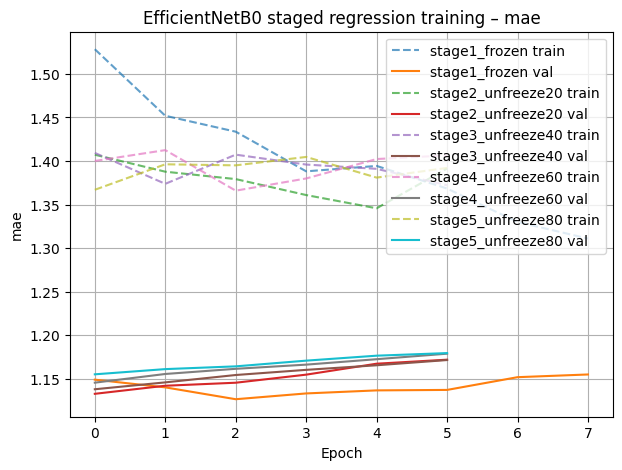

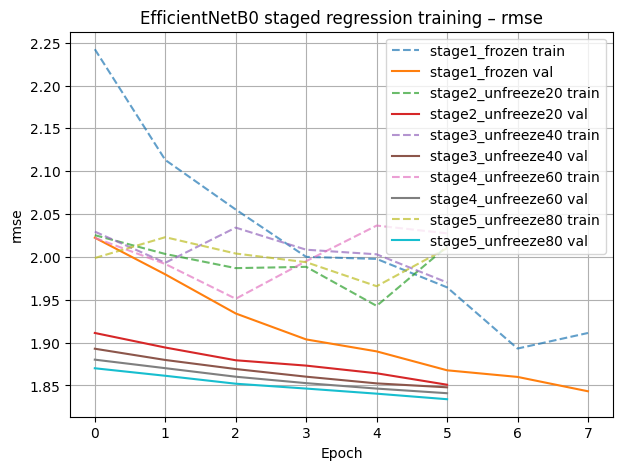

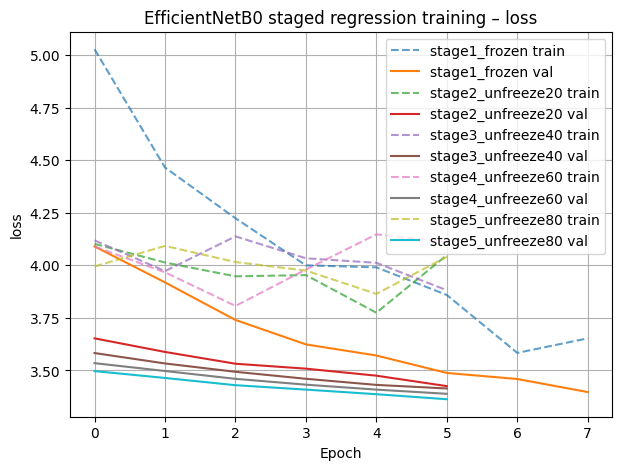

In [15]:
def plot_stage_histories(histories_dict: dict[str, dict[str, list[float]]], metric: str = "mae") -> None:
    plt.figure(figsize=(7, 5))

    for name, history in histories_dict.items():
        if metric in history:
            plt.plot(history[metric], linestyle="--", alpha=0.7, label=f"{name} train")
        if f"val_{metric}" in history:
            plt.plot(history[f"val_{metric}"], label=f"{name} val")

    plt.xlabel("Epoch")
    plt.ylabel(metric)
    plt.title(f"EfficientNetB0 staged regression training – {metric}")
    plt.legend()
    plt.grid(True)
    plt.show()

plot_stage_histories(stage_histories, metric="mae")
plot_stage_histories(stage_histories, metric="rmse")
plot_stage_histories(stage_histories, metric="loss")

## 📉 14. Predicted vs true `target_SE`

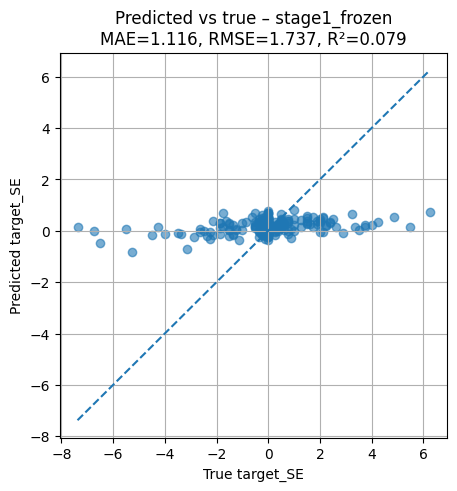

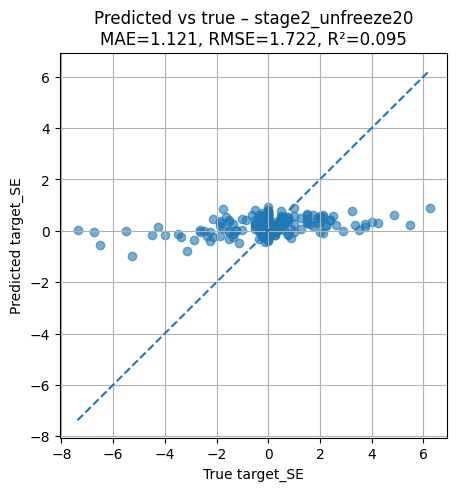

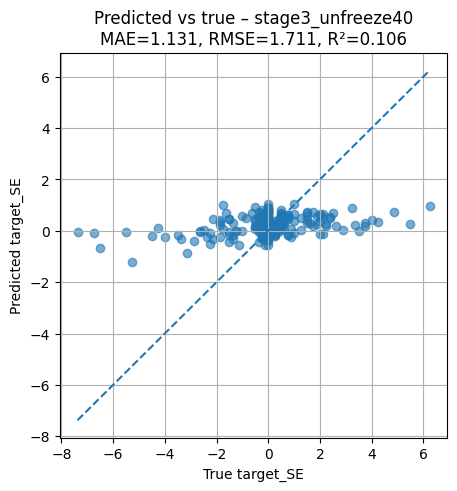

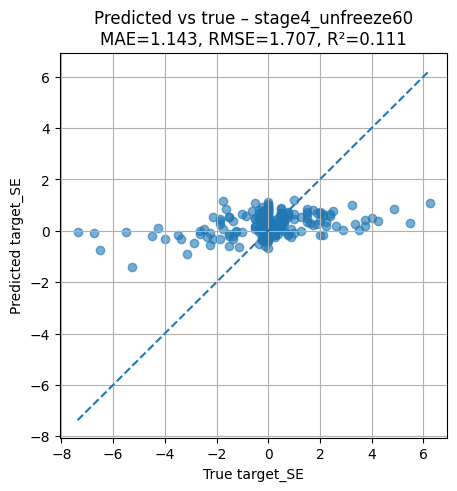

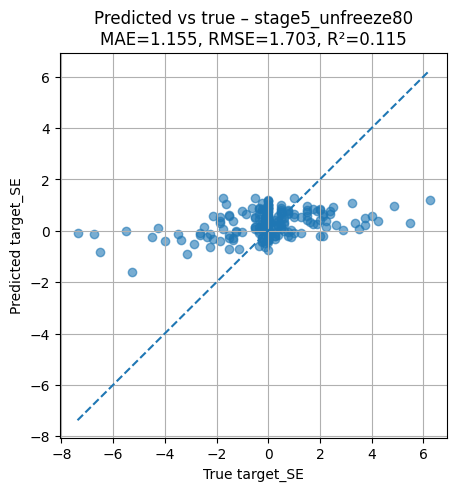

In [16]:
def plot_predictions_from_summaries(stage_summaries: list[dict[str, Any]]) -> None:
    for summary in stage_summaries:
        ev = summary["evaluation"]
        y_true = np.array(ev["y_true"], dtype=float)
        y_pred = np.array(ev["y_pred"], dtype=float)

        plt.figure(figsize=(5, 5))
        plt.scatter(y_true, y_pred, alpha=0.6)

        min_val = min(y_true.min(), y_pred.min())
        max_val = max(y_true.max(), y_pred.max())
        plt.plot([min_val, max_val], [min_val, max_val], linestyle="--")

        plt.xlabel("True target_SE")
        plt.ylabel("Predicted target_SE")
        plt.title(
            f"Predicted vs true – {summary['stage_name']}\n"
            f"MAE={ev['mae']:.3f}, RMSE={ev['rmse']:.3f}, R²={ev['r2']:.3f}"
        )
        plt.grid(True)
        plt.show()

plot_predictions_from_summaries(stage_summaries)

## 📊 15. Residual plots


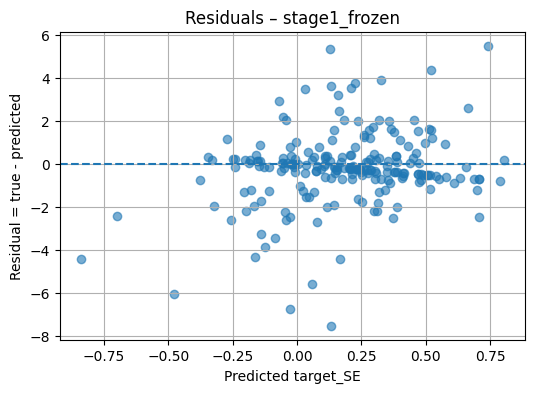

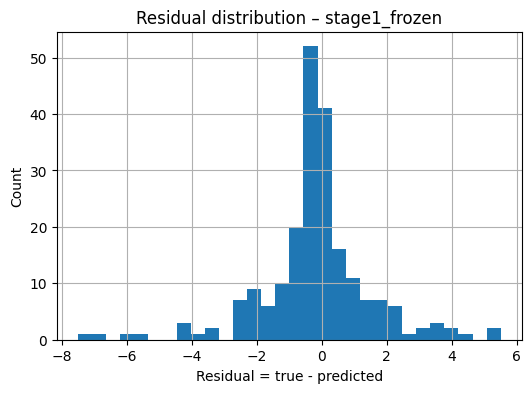

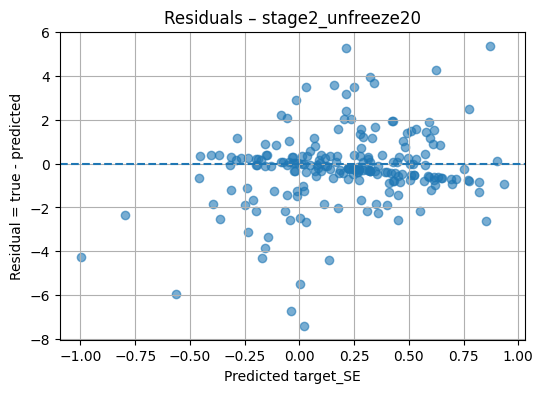

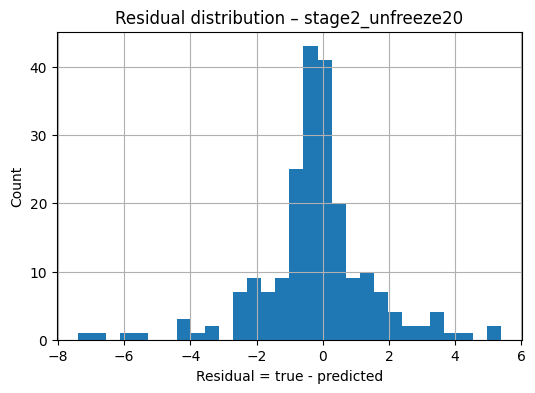

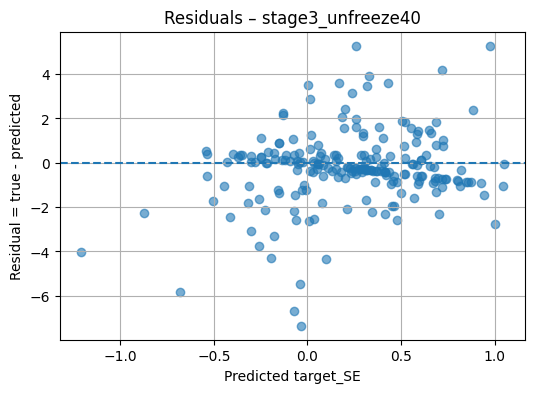

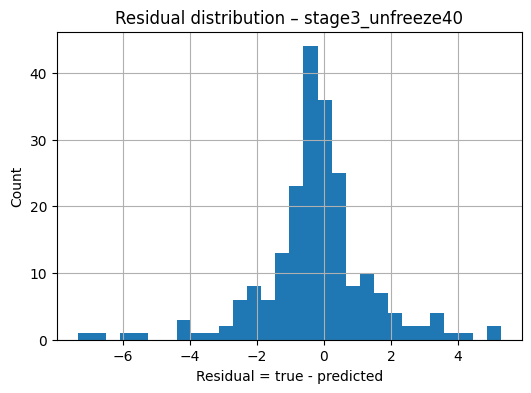

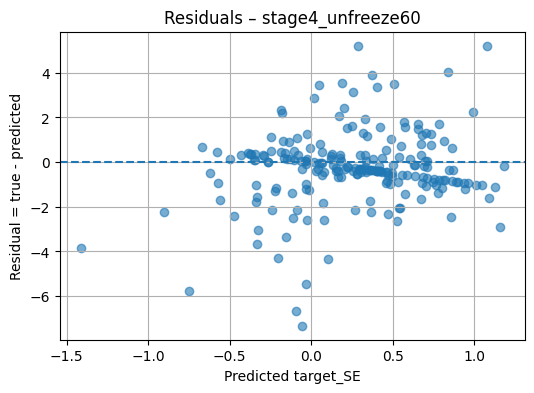

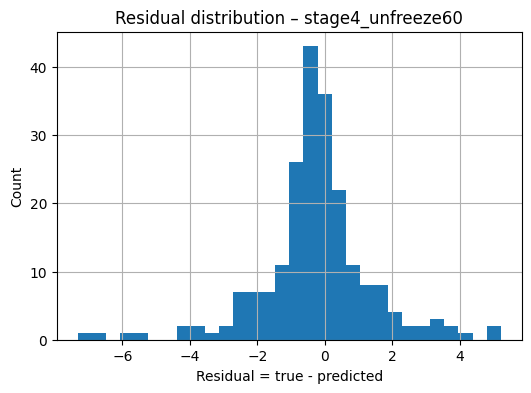

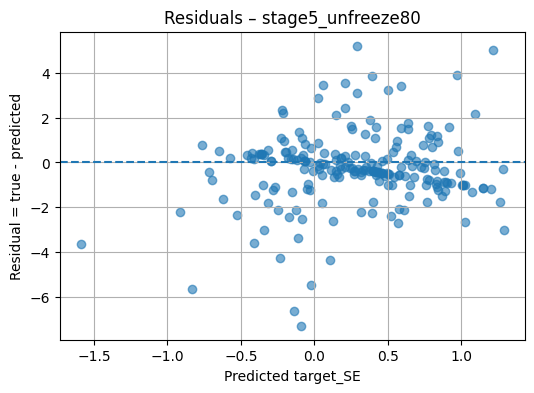

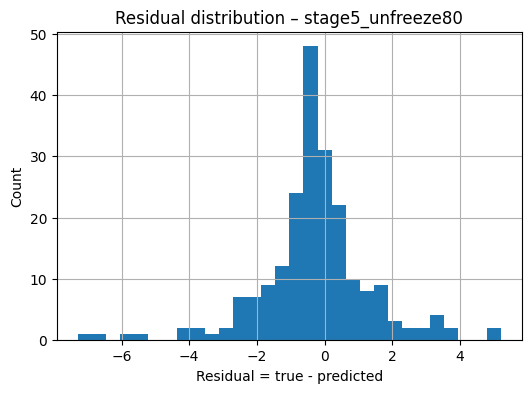

In [17]:
def plot_residuals_from_summaries(stage_summaries: list[dict[str, Any]]) -> None:
    for summary in stage_summaries:
        ev = summary["evaluation"]
        y_pred = np.array(ev["y_pred"], dtype=float)
        residuals = np.array(ev["residuals"], dtype=float)

        plt.figure(figsize=(6, 4))
        plt.scatter(y_pred, residuals, alpha=0.6)
        plt.axhline(0, linestyle="--")
        plt.xlabel("Predicted target_SE")
        plt.ylabel("Residual = true - predicted")
        plt.title(f"Residuals – {summary['stage_name']}")
        plt.grid(True)
        plt.show()

        plt.figure(figsize=(6, 4))
        plt.hist(residuals, bins=30)
        plt.xlabel("Residual = true - predicted")
        plt.ylabel("Count")
        plt.title(f"Residual distribution – {summary['stage_name']}")
        plt.grid(True)
        plt.show()

plot_residuals_from_summaries(stage_summaries)

## 📝 16. Results template


Short text skeleton that can be adapted for the TFG results section.


In [18]:
best_mae_row = results_df.sort_values("test_mae", ascending=True).iloc[0]
best_r2_row = results_df.sort_values("test_r2", ascending=False).iloc[0]

print("Best stage by MAE:")
print(best_mae_row[["stage_name", "test_mae", "test_rmse", "test_r2", "baseline_mae"]])

print("\nBest stage by R²:")
print(best_r2_row[["stage_name", "test_mae", "test_rmse", "test_r2", "baseline_r2"]])

Best stage by MAE:
stage_name      stage1_frozen
test_mae             1.115825
test_rmse            1.736542
test_r2              0.079471
baseline_mae         1.093387
Name: 0, dtype: object

Best stage by R²:
stage_name     stage5_unfreeze80
test_mae                 1.15525
test_rmse                1.70312
test_r2                 0.114563
baseline_r2            -0.000185
Name: 4, dtype: object


-> Regresión: Stage 5 tiene mejor R2 y RMSE, pero S1 gana en MAE. De todas maneras, como ningún stage mejora el baseline en MAE, conviene no fijarse tanto en MAE.
Por tanto "gana" S5, que parece que encuentra más señal.